#Mathematical Modeling of Traffic Flow Composition and Load Equivalency Factors

**Author:** Dr. Ing. Boris Yotsov  
**Course:** Math Concepts for Developers  
**Final Project**

**Abstract**: This project investigates the relationship between vehicle axle loads and pavement damage using the classical fourth power law. A probabilistic approach using Monte Carlo simulation is applied to analyze the variability of Load Equivalency Factors (LEF) and their relationship to Bulgarian pavement design vehicles. The report analyzes data on the composition of traffic flow and Load Equivalency Factors related to the flexible pavement design. Control profile counts have been carried out on different classes of roads in order to divide heavy goods traffic into additional subclasses.The truck factors for vehicle class 4 (Trucks with trailer and TIR) were calculated.

**Keywords:** Keywords: Load Equivalency Factor, Pavement Design, Monte Carlo Simulation, Traffic Engineering

###1. Introduction

Road pavement design requires an accurate estimation of traffic loading during the design life of the road. Traffic loads are one of the main factors influencing pavement deterioration. One of the key parameters in pavement design is the conversion of different vehicle types into equivalent standard vehicles or equivalent axle loads.

In many countries, including Bulgaria, the conversion coefficients for heavy vehicles were developed several decades ago. However, freight transport has changed significantly in recent years due to the increased share of heavy trucks and new vehicle configurations.

As a result, the currently used coefficients may not accurately represent the real loading conditions imposed by modern traffic. This study analyzes the composition of heavy vehicle traffic and estimates updated load equivalency factors using statistical analysis and Monte Carlo simulation implemented in Python.

The objective of this project is to analyze load equivalency factors using measured axle load data and probabilistic simulation, and to compare the results with the values used in the Bulgarian pavement design standards.

The project combines:

- mathematical modeling
- statistical distributions
- Monte Carlo simulation
- data visualization

###2. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###3. Load Traffic Dataset

Traffic data were obtained from manual counting on the vehicle counting stations. Heavy vehicles were classified according to the number of axles and vehicle configuration.
The parameters used in this model are based on traffic measurements and statistical distributions of truck weights.

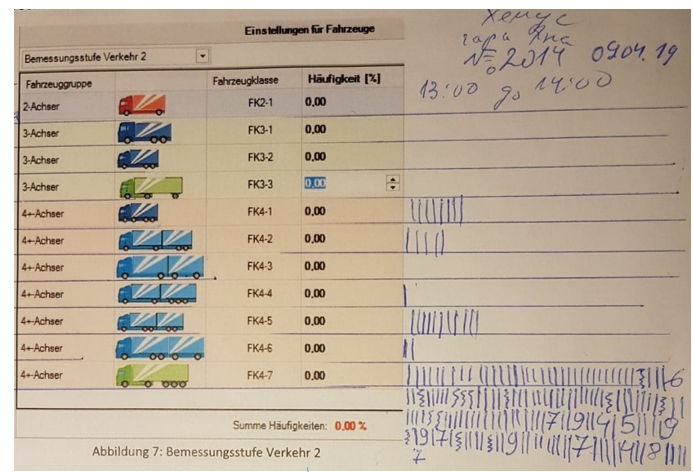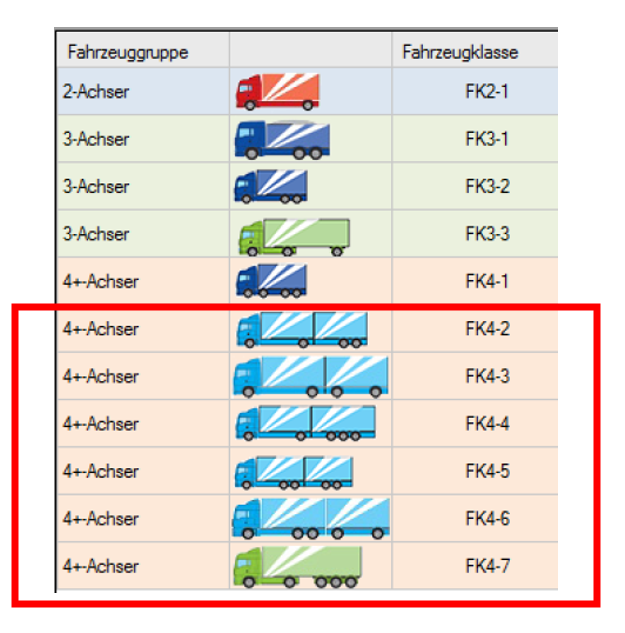

Figure 1. Sample of a completed form for visual traffic counting

Figure 2: Traffic load. Austria. The vehicle groups (Fahrzeuggruppe) are shown on the left and the vehicle sub-groups (Fahzeugklasse) on the right [1].

Table 1 Motor vehicle groups Bulgaria [Dimensioning vehicles] [2]

In [3]:
url = "https://github.com/borisyotsov/traffic-load-equivalency-model/raw/refs/heads/main/data/traffic_data.xlsx"

traffic_data = pd.read_excel(url, sheet_name="load_equivalency_factor_BG", header = 1)

traffic_data


,Truck types,100 kN/axle,115 kN/axle
0,Light trucks,0.03,0.0050
1,Medium trucks,0.20,0.0570
2,Heavy trucks,1.00,0.7705
3,Truck-trailer combinations and articulated tru...,1.00,1.7150
4,Buses,0.80,0.5410


Table 2: Total percentage distribution of relevant class 4 vehicles. Trucks with trailers and TIR on roads with different load classes [%], obtained from all control profile counts to date (September 27, 2020)

In [4]:
import pandas as pd

truck_types = pd.DataFrame({
    "Truck_type": [
        "FK4-2",
        "FK4-3",
        "FK4-4",
        "FK4-5",
        "FK4-6",
        "FK4-7"
    ],

    "Light [%]": [10.00, 0.00, 0.00, 10.00, 0.00, 80.00],

    "Medium [%]": [12.50, 3.57, 0.00, 1.79, 1.79, 80.36],

    "Heavy [%]": [5.73, 2.29, 0.00, 4.96, 1.53, 85.50],

    "Very Heavy [%]": [12.14, 4.29, 0.00, 1.43, 0.00, 82.14],

    "Motorway [%]": [1.84, 0.28, 0.44, 4.42, 1.66, 91.36]
})

truck_types

,Truck_type,Light [%],Medium [%],Heavy [%],Very Heavy [%],Motorway [%]
0,FK4-2,10.0,12.50,5.73,12.14,1.84
1,FK4-3,0.0,3.57,2.29,4.29,0.28
2,FK4-4,0.0,0.00,0.00,0.00,0.44
3,FK4-5,10.0,1.79,4.96,1.43,4.42
4,FK4-6,0.0,1.79,1.53,0.00,1.66
5,FK4-7,80.0,80.36,85.50,82.14,91.36


###4. Mathematical Model

The number of equivalent vehicles can be estimated as::

$$ N_e = \sum_{s=1}^{7} N_sLEF_s  $$






where:

$ N_e $ – design traffic intensity per day, number of design vehicles / 24 h

$ N_s $ – average annual daily traffic of vehicle type s

$ LEF_s $ – load equivalency factor

The relationship between axle load and pavement damage is described by the **fourth power law**, originally derived from the AASHO Road Test.

For a vehicle with multiple axles the total load equivalency factor is the sum of the axle contributions.

The load equivalency factor for an axle is calculated as:

$$ LEF_{vehicle} = \sum_{i=1}^{n} \left(\frac{L_{i}}{L_{std}}\right)^4 $$

where:

$ L $ – axle load in kN

$ L_{std} $ – reference standard axle load (100 kN)

This value represents the number of equivalent standard axles (ESAL).

Truck weights are modeled using a mixture of two normal distributions:

$$ GW = g_1N_1(\mu_1,\sigma_1)+g_2N_2(\mu_2,\sigma_2) $$

where:

GW – Vehicle weight distribution

$ g_1, g_2 $ – weighting coefficients

$ N_1, N_2 $ – probability density functions of the normal distribution

$\mu_1, \mu_2 $ – mean values of the normal distribution

$ \sigma_1, \sigma_2 $ – standard deviations

This model represents variability in truck weights observed in real traffic.



$$ N_1 = \mu_1 + \sigma_1 $$

Table 3: Parameters for determining the total weight of vehicle classes in class 4. Trucks with trailers and TIR, divided into subclasses according to the Austrian methodology for standard transport flow in Austria [1]

In [5]:
url = "https://github.com/borisyotsov/traffic-load-equivalency-model/raw/refs/heads/main/data/traffic_data.xlsx"

traffic_weights = pd.read_excel(url, sheet_name="total_weight")

traffic_weights

,Unnamed: 0,g1,μ1,σ1,g2,μ2,σ2,N1,N2,Total weight [kN]
0,FK4-2,0.40,181.2,41.87,0.60,262.6,64.82,223.07,327.42,285.68
1,FK4-3,0.85,208.4,49.21,0.15,302.3,68.91,257.61,371.21,274.65
2,FK4-4,0.68,295.2,84.72,0.32,404.9,32.88,379.92,437.78,398.44
3,FK4-5,0.37,254.4,58.59,0.63,336.9,64.93,312.99,401.83,368.96
4,FK4-6,0.49,247.3,48.95,0.51,380.4,67.37,296.25,447.77,373.53
5,FK4-7,0.38,407.1,34.94,0.62,305.7,88.79,442.04,394.49,412.56


The axle load is estimated using a linear relationship:

$$ L_i = \beta_i + \alpha_iGW $$

This model is implemented in Python to simulate traffic loading using Monte Carlo methods.

where:

$ L_i $– load of the i-th axle in [kN]

GW – gross vehicle weight in the corresponding subclass

$ \alpha_i, \beta_i $ – axle load coefficients for the i-th axle of the considered vehicle subclass according to Table 4.





Table 4: Axle weights of vehicle classes in class 4. Goods vehicles with trailers and TIR, divided into subclasses according to the Austrian methodology [kN]

In [6]:
url = "https://github.com/borisyotsov/traffic-load-equivalency-model/raw/refs/heads/main/data/traffic_data.xlsx"

Axle_weights = pd.read_excel(url, sheet_name="Axle_weights")

Axle_weights

,Axle Weights [kN],Axle 1,Axle 2,Axle 3,Axle 4,Alxle 5
0,FK4-2,70.57,89.84,60.68,61.70,0.00
1,FK4-3,65.11,88.38,61.07,60.07,0.00
2,FK4-4,73.50,98.85,74.94,72.83,74.26
3,FK4-5,70.84,90.59,66.69,69.00,71.59
4,FK4-6,74.28,86.28,68.86,76.75,74.89
5,FK4-7,75.31,104.51,78.19,79.32,79.42


The weighted average value of the conversion coefficient for class 4 Goods vehicles with trailers and TIR for the different types of traffic was calculated from the percentage ratio of the subclasses of vehicles for the different types of traffic and from the conversion coefficients obtained for these classes of vehicles.

### 5. Relationship Between Axle Load and Pavement Damage (scatter на fourth power law)

This figure illustrates the well-known Fourth Power Law in pavement engineering.
It demonstrates that pavement damage increases nonlinearly with axle load.
Even a small increase in axle load can lead to a significant increase in pavement deterioration.

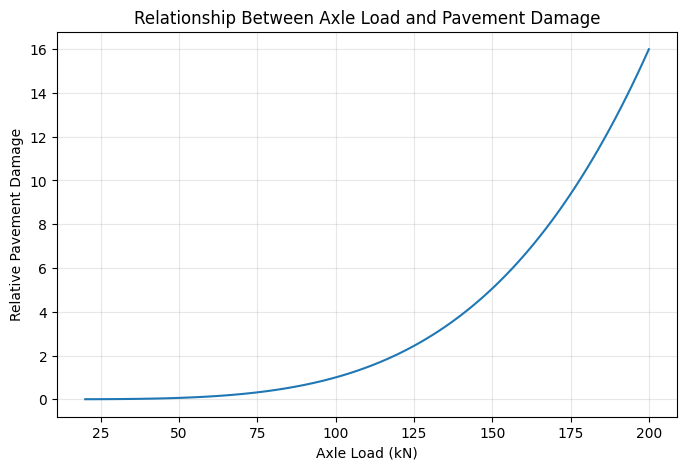

In [7]:
axle_load = np.linspace(20, 200, 100)

damage = (axle_load / 100) ** 4

plt.figure(figsize=(8,5))

plt.plot(axle_load, damage)

plt.xlabel("Axle Load (kN)")
plt.ylabel("Relative Pavement Damage")

plt.title("Relationship Between Axle Load and Pavement Damage")

plt.grid(alpha=0.3)

plt.show()

###6. Bulgarian Design Vehicles

In Bulgarian pavement design practice, traffic loads are often expressed relative to predefined **design vehicles**.

Two reference vehicles are commonly used:

Design Vehicle 1  
Front axle = 60 kN  
Rear axle = 100 kN  

Design Vehicle 2  
Front axle = 70 kN  
Rear axle = 115 kN  

The equivalency of these vehicles relative to the 100 kN standard axle is calculated using the same fourth power law.

Table 4: Calculated conversion factors for class 4. Goods vehicles with trailers and TIR for the different traffic categories

In [8]:
url = "https://github.com/borisyotsov/traffic-load-equivalency-model/raw/refs/heads/main/data/traffic_data.xlsx"

Calculated_lef = pd.read_excel(url, sheet_name="Calculated_lef")

Calculated_lef

,Truck-trailer combinations and articulated trucks (TIR),Light,Medium,Heavy,Very Heavy,Motorway,Value in the norm in BG
0,load equivalency factor dimension vehicle 100k...,1.699,1.715,1.765,1.726,1.825,1.000
1,load equivalency factor dimension vehicle 115...,0.940,0.979,1.007,0.985,1.041,1.715


In [9]:
traffic_categories = ["Light","Medium","Heavy","Very Heavy","Motorway"]

lef_oa1 = Calculated_lef.loc[0, traffic_categories]
lef_oa2 = Calculated_lef.loc[1, traffic_categories]

bg_norm_oa1 = Calculated_lef.loc[0, "Value in the norm in BG"]
bg_norm_oa2 = Calculated_lef.loc[1, "Value in the norm in BG"]


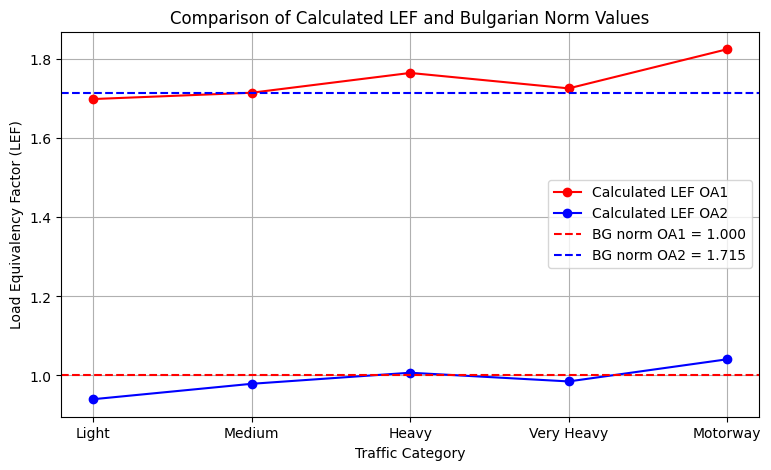

In [10]:
plt.figure(figsize=(9,5))

plt.plot(traffic_categories, lef_oa1, marker="o", label="Calculated LEF OA1", c = "r")

plt.plot(traffic_categories, lef_oa2, marker="o", label="Calculated LEF OA2", c = "b")

# horizontal lines from the Bulgarian norm
plt.axhline(bg_norm_oa1, linestyle="--", label="BG norm OA1 = 1.000", c = "r")

plt.axhline(bg_norm_oa2, linestyle="--", label="BG norm OA2 = 1.715", c = "b")


plt.xlabel("Traffic Category")

plt.ylabel("Load Equivalency Factor (LEF)")

plt.title("Comparison of Calculated LEF and Bulgarian Norm Values")

plt.legend()

plt.grid(True)


plt.show()

The figure compares the calculated load equivalency factors for different traffic categories with the reference values defined in the Bulgarian pavement design standards.

The horizontal lines represent the normative LEF values used in practice, while the calculated values reflect the results obtained from the axle load data.


###7. Monte Carlo Simulation (truck weights)

Monte Carlo simulation is used to generate random truck weights according to the statistical distributions.

This allows us to estimate the resulting distribution of load equivalency factors.

In [11]:
num_simulations = 20000
standard_axle_load = 100


simulated_weights = []
simulated_lef = []

for _ in range(num_simulations):

    for index, row in traffic_weights.iterrows():

        g1 = row["g1"]
        mu1 = row["μ1"]
        sigma1 = row["σ1"]

        g2 = row["g2"]
        mu2 = row["μ2"]
        sigma2 = row["σ2"]

        if np.random.rand() < g1:
            gw = np.random.normal(mu1, sigma1)
        else:
            gw = np.random.normal(mu2, sigma2)

        simulated_weights.append(gw)

###8. Distribution of Simulated Truck Weights

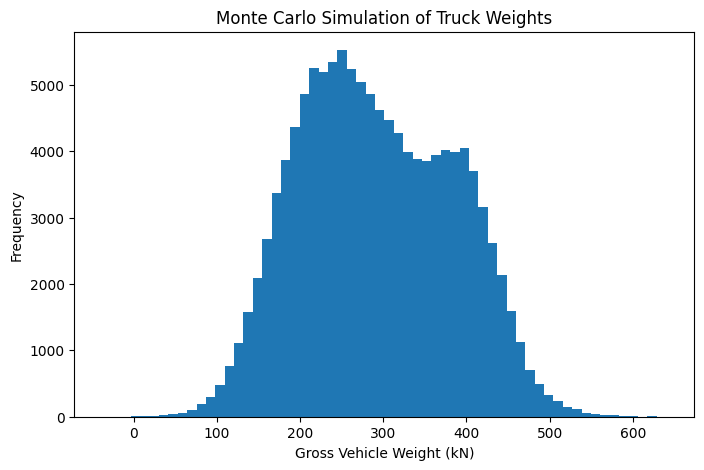

In [12]:
plt.figure(figsize=(8,5))

plt.hist(simulated_weights, bins=60)

plt.xlabel("Gross Vehicle Weight (kN)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation of Truck Weights")

plt.show()

###9. Calculate Vehicle LEF

In [13]:
standard_axle_load = 100

axle_columns = ["Axle 1","Axle 2","Axle 3","Axle 4","Alxle 5"]

def calculate_lef(row):

    lef = 0

    for axle in axle_columns:
        load = row[axle]

        if load > 0:
            lef += (load / standard_axle_load) ** 4

    return lef

Axle_weights["LEF_100kN"] = Axle_weights.apply(calculate_lef, axis=1)

Axle_weights

,Axle Weights [kN],Axle 1,Axle 2,Axle 3,Axle 4,Alxle 5,LEF_100kN
0,FK4-2,70.57,89.84,60.68,61.70,0.00,1.179963
1,FK4-3,65.11,88.38,61.07,60.07,0.00,1.059140
2,FK4-4,73.50,98.85,74.94,72.83,74.26,2.147474
3,FK4-5,70.84,90.59,66.69,69.00,71.59,1.612456
4,FK4-6,74.28,86.28,68.86,76.75,74.89,1.744975
5,FK4-7,75.31,104.51,78.19,79.32,79.42,2.682116


###10. Design Vehicle Equivalency

In [14]:
LEF_OA1 = (60/100)**4 + (100/100)**4
LEF_OA2 = (70/100)**4 + (115/100)**4

Axle_weights["LEF_OA1"] = Axle_weights["LEF_100kN"] / LEF_OA1
Axle_weights["LEF_OA2"] = Axle_weights["LEF_100kN"] / LEF_OA2

Axle_weights

,Axle Weights [kN],Axle 1,Axle 2,Axle 3,Axle 4,Alxle 5,LEF_100kN,LEF_OA1,LEF_OA2
0,FK4-2,70.57,89.84,60.68,61.70,0.00,1.179963,1.044585,0.593213
1,FK4-3,65.11,88.38,61.07,60.07,0.00,1.059140,0.937624,0.532470
2,FK4-4,73.50,98.85,74.94,72.83,74.26,2.147474,1.901093,1.079618
3,FK4-5,70.84,90.59,66.69,69.00,71.59,1.612456,1.427458,0.810644
4,FK4-6,74.28,86.28,68.86,76.75,74.89,1.744975,1.544773,0.877266
5,FK4-7,75.31,104.51,78.19,79.32,79.42,2.682116,2.374394,1.348402


##11. Monte Carlo Simulation 1

In the Monte Carlo simulation, axle loads are assumed to vary around their measured values. A normal distribution with a 10% standard deviation is used to simulate variability in vehicle loading.

In [15]:
n_simulations = 10000

simulated_lef = []

for i in range(n_simulations):

    vehicle = Axle_weights.sample(1)

    lef = 0

    for axle in axle_columns:

        load = vehicle[axle].values[0]

        if load > 0:

            simulated_load = np.random.normal(load, load*0.1)

            lef += (simulated_load / 100) ** 4

    simulated_lef.append(lef)

simulated_lef = np.array(simulated_lef)

mean_lef = np.mean(simulated_lef)

median_lef = np.median(simulated_lef)

std_lef = np.std(simulated_lef)

###12. Distribution of Simulated LEF 1

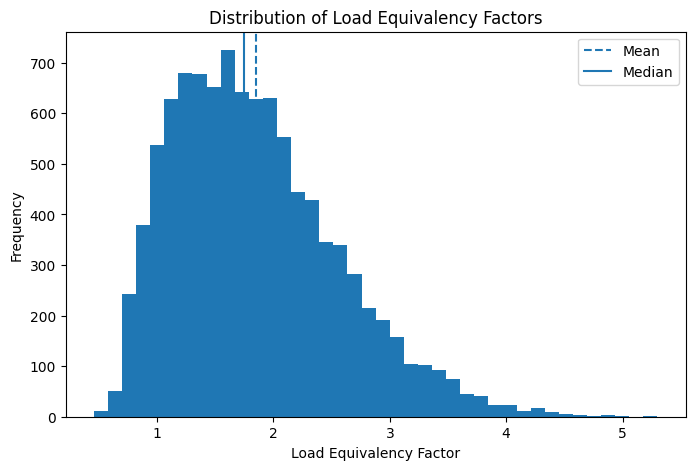

In [16]:
plt.figure(figsize=(8,5))

plt.hist(simulated_lef, bins=40)

plt.axvline(mean_lef, linestyle='dashed', label="Mean")

plt.axvline(median_lef, linestyle='solid', label="Median")

plt.xlabel("Load Equivalency Factor")

plt.ylabel("Frequency")

plt.title("Distribution of Load Equivalency Factors")

plt.legend()

plt.show()

In [17]:
simulated_lef_df = pd.DataFrame(simulated_lef, columns=["LEF"])

simulated_lef_df.describe().T

,count,mean,std,min,25%,50%,75%,max
LEF,10000.0,1.848233,0.712409,0.456157,1.297708,1.744021,2.278912,5.300188


###13. Monte Carlo Simulation 2

In the Monte Carlo simulation, axle loads are assumed to vary around their measured values. A normal distribution with a 20% standard deviation is used to simulate variability in vehicle loading.

In [18]:
n_simulations = 10000

simulated_lef2 = []

for i in range(n_simulations):

    vehicle = Axle_weights.sample(1)

    lef = 0

    for axle in axle_columns:

        load = vehicle[axle].values[0]

        if load > 0:

            simulated_load = np.random.normal(load, load*0.2)

            lef += (simulated_load / 100) ** 4

    simulated_lef2.append(lef)

simulated_lef2 = np.array(simulated_lef2)

mean_lef2 = np.mean(simulated_lef2)

median_lef2 = np.median(simulated_lef2)

std_lef2 = np.std(simulated_lef2)

###14. Distribution of Simulated LEF 2

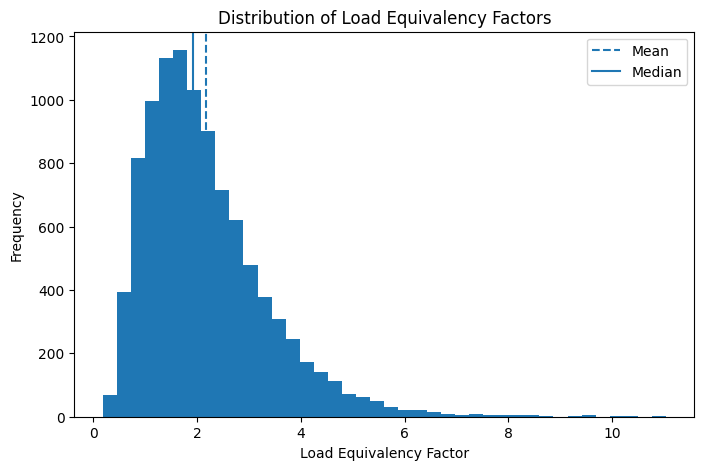

In [19]:
plt.figure(figsize=(8,5))

plt.hist(simulated_lef2, bins=40)

plt.axvline(mean_lef2, linestyle='dashed', label="Mean")

plt.axvline(median_lef2, linestyle='solid', label="Median")

plt.xlabel("Load Equivalency Factor")

plt.ylabel("Frequency")

plt.title("Distribution of Load Equivalency Factors")

plt.legend()

plt.show()

In [20]:
simulated_lef_df2 = pd.DataFrame(simulated_lef2, columns=["LEF"])

simulated_lef_df2.describe().T

,count,mean,std,min,25%,50%,75%,max
LEF,10000.0,2.167213,1.187573,0.182809,1.327655,1.926289,2.755026,11.039859


###15. Pavement Damage vs Axle Load (Log Scale)

The fourth power law suggests that pavement damage increases exponentially with axle load.

A logarithmic scale allows better visualization of this nonlinear relationship. It compresses large damage values while making smaller values more visible, which helps illustrate how even small increases in axle load can lead to significantly higher pavement deterioration.

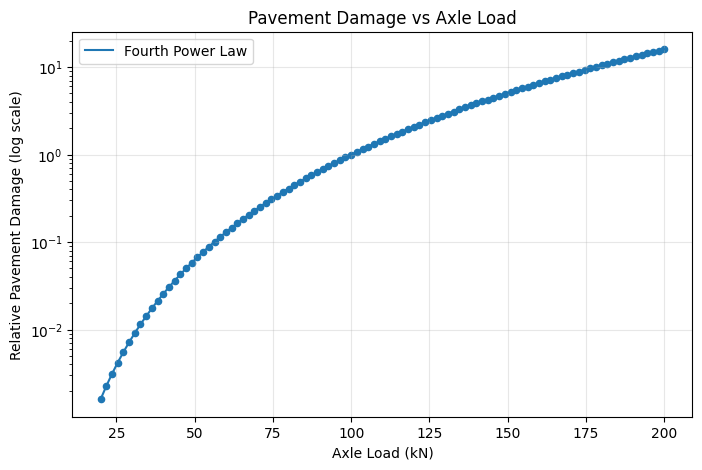

In [21]:
axle_load = np.linspace(20, 200, 100)

damage = (axle_load / 100) ** 4

plt.figure(figsize=(8,5))

plt.plot(axle_load, damage, label="Fourth Power Law")

plt.scatter(axle_load, damage, s=20)

plt.yscale("log")

plt.xlabel("Axle Load (kN)")

plt.ylabel("Relative Pavement Damage (log scale)")

plt.title("Pavement Damage vs Axle Load")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

###16. Confidence Interval

To estimate the uncertainty of the simulation results we calculate a 95% confidence interval for the mean LEF.

The confidence interval for the mean is calculated as:

$$ CI = \bar{x} \pm z\,\frac{\sigma}{\sqrt{n}} $$

where:

$ \bar{x} $ = smple mean

$ \sigma $ = standard deviation

n = sample size

In [23]:
mean_lef = np.mean(simulated_lef)

std_lef = np.std(simulated_lef)

n = len(simulated_lef)

confidence_interval = (
    mean_lef - 1.96 * std_lef / np.sqrt(n),
    mean_lef + 1.96 * std_lef / np.sqrt(n)
)

mean_lef, confidence_interval

(np.float64(1.8482330188221885),
 (np.float64(1.83427049889051), np.float64(1.862195538753867)))

###17. Discussion

The results show that heavy vehicles contribute significantly to pavement loading. The Monte Carlo simulation allows the variability of truck weights and traffic composition to be taken into account.

Compared with traditional deterministic approaches, this probabilistic model provides a more realistic estimation of traffic loading.

###18. Conclusions

This project demonstrated how mathematical models can be applied to traffic load analysis.

The fourth power law provides a simple yet powerful relationship between axle loads and pavement damage. By combining this model with Monte Carlo simulation, it is possible to analyze the variability of load equivalency factors and estimate statistical properties such as mean values and confidence intervals.

The results were also converted to load equivalency relative to Bulgarian design vehicles, allowing the model to be interpreted within the context of national pavement design practice.

This approach illustrates the usefulness of mathematical modeling and probabilistic simulation in modern pavement engineering.
The results indicate that the effective load equivalency factor for heavy vehicles may be significantly higher than the currently used values. Updating these coefficients could improve the accuracy of pavement design and better reflect modern traffic conditions.

###19. REFERENCES

[1]	Bundesministerium für Verkehr, Innovation und Technologie (BMVIT). Österreichische Forschungsgesellschaft Straße - Schiene - Verkehr (FSV), RVS 03.08.68 Rechnerische Dimensionierung von Asphaltstrassen. Vienna, 2019.

[2]	Tsentralna laboratoriya po patishta I mostove, Izpalnitelna agentsiya patishta. Rakovodstvo za orazmeryavane na asfaltovi nastilki, Sofia, 2002.

[3]	American Association of State highway and Transportaion Officials, AASHTO Guide for Design of Pavement Struktures 1993. Washington, 1993.

[4] NumPy Documentation

[5] Pandas Documentation
